In [1]:
import numpy as np
import pandas as pd
import nltk
import re
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from sklearn.metrics import confusion_matrix

In [2]:
# Download required resources
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

True

In [3]:
df = pd.read_csv('./data/train.csv')

In [26]:
# Drop the 'id' column if it exists
if 'id' in df.columns:
    df = df.drop(columns=['id'])

# Select a sample article and its reference summary
article = df.loc[0, 'article'] 
reference_summary = df.loc[0, 'highlights']  

# Preprocess text
stop_words = set(stopwords.words('english'))

# Tokenize sentences
sentences = sent_tokenize(article)

# Remove stopwords and special characters
def preprocess_text(text):
    text = re.sub(r'\W', ' ', text)  # Remove special characters
    words = word_tokenize(text.lower())  # Tokenize and convert to lowercase
    words = [word for word in words if word not in stop_words]  # Remove stopwords
    return ' '.join(words)

processed_sentences = [preprocess_text(sentence) for sentence in sentences]

In [27]:
# Compute sentence similarity using Jaccard Similarity
def sentence_similarity(sent1, sent2):
    words1 = set(sent1.split())
    words2 = set(sent2.split())
    return len(words1 & words2) / max(len(words1 | words2), 1)  # Jaccard Similarity

# Build similarity matrix
similarity_matrix = np.zeros((len(sentences), len(sentences)))
for i in range(len(sentences)):
    for j in range(len(sentences)):
        if i != j:
            similarity_matrix[i][j] = sentence_similarity(processed_sentences[i], processed_sentences[j])


In [28]:
# Apply TextRank algorithm using NetworkX
graph = nx.from_numpy_array(similarity_matrix)
scores = nx.pagerank(graph)

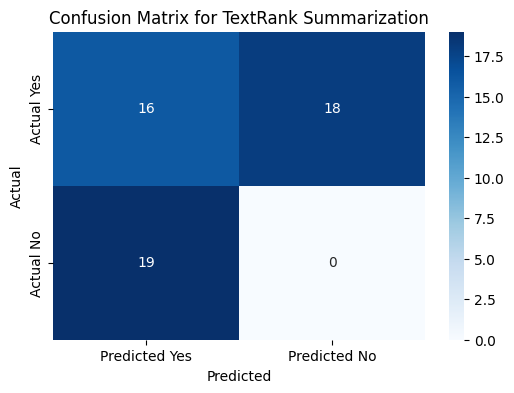


Generated Summary:
 Bishop John Folda (pictured) of the Fargo Catholic Diocese in North Dakota has exposed potentially hundreds of church members in Fargo, Grand Forks and Jamestown to the hepatitis A . The bishop of the Fargo Catholic Diocese in North Dakota has exposed potentially hundreds of church members in Fargo, Grand Forks and Jamestown to the hepatitis A virus in late September and early October. Fargo Catholic Diocese in North Dakota (pictured) is where the bishop is located .

Reference Summary:
 Bishop John Folda, of North Dakota, is taking time off after being diagnosed .
He contracted the infection through contaminated food in Italy .
Church members in Fargo, Grand Forks and Jamestown could have been exposed .


In [29]:
# Rank sentences based on TextRank scores
ranked_sentences = sorted(((scores[i], s) for i, s in enumerate(sentences)), reverse=True)

# Generate summary (top 3 ranked sentences)
top_n = 3
generated_summary = ' '.join([ranked_sentences[i][1] for i in range(min(top_n, len(ranked_sentences)))])

# Convert summaries to sets of words
reference_words = set(reference_summary.lower().split())
generated_words = set(generated_summary.lower().split())

# Calculate True Positives, False Positives, False Negatives
true_positive = len(reference_words & generated_words)
false_positive = len(generated_words - reference_words)
false_negative = len(reference_words - generated_words)

# Confusion Matrix
conf_matrix = np.array([[true_positive, false_negative], [false_positive, 0]])

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Predicted Yes", "Predicted No"], yticklabels=["Actual Yes", "Actual No"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for TextRank Summarization")
plt.show()

# Print Summaries
print("\nGenerated Summary:\n", generated_summary)
print("\nReference Summary:\n", reference_summary)

In [4]:
# ROUGE Evaluation for Text Summarization
from rouge_score import rouge_scorer
import json
from typing import List, Dict, Tuple

class TextRankSummarizer:
    """
    A complete TextRank-based extractive text summarizer with evaluation capabilities
    """
    
    def __init__(self, top_n: int = 3, similarity_threshold: float = 0.1):
        self.top_n = top_n
        self.similarity_threshold = similarity_threshold
        self.stop_words = set(stopwords.words('english'))
    
    def preprocess_text(self, text: str) -> str:
        """Preprocess text by removing special characters and stopwords"""
        text = re.sub(r'\W', ' ', text)
        words = word_tokenize(text.lower())
        words = [word for word in words if word not in self.stop_words and len(word) > 2]
        return ' '.join(words)
    
    def sentence_similarity(self, sent1: str, sent2: str) -> float:
        """Calculate Jaccard similarity between two sentences"""
        words1 = set(sent1.split())
        words2 = set(sent2.split())
        intersection = len(words1 & words2)
        union = len(words1 | words2)
        return intersection / max(union, 1)
    
    def summarize(self, article: str) -> Tuple[str, Dict]:
        """
        Generate extractive summary using TextRank algorithm
        Returns: (summary_text, metadata)
        """
        # Tokenize sentences
        sentences = sent_tokenize(article)
        
        if len(sentences) <= self.top_n:
            return ' '.join(sentences), {"num_sentences": len(sentences), "compression_ratio": 1.0}
        
        # Preprocess sentences
        processed_sentences = [self.preprocess_text(sentence) for sentence in sentences]
        
        # Build similarity matrix
        similarity_matrix = np.zeros((len(sentences), len(sentences)))
        for i in range(len(sentences)):
            for j in range(len(sentences)):
                if i != j:
                    similarity_matrix[i][j] = self.sentence_similarity(
                        processed_sentences[i], processed_sentences[j]
                    )
        
        # Apply TextRank algorithm
        graph = nx.from_numpy_array(similarity_matrix)
        scores = nx.pagerank(graph)
        
        # Rank sentences and select top ones
        ranked_sentences = sorted(
            ((scores[i], i, s) for i, s in enumerate(sentences)), 
            reverse=True
        )
        
        # Get top sentences in original order
        top_indices = sorted([ranked_sentences[i][1] for i in range(self.top_n)])
        summary = ' '.join([sentences[i] for i in top_indices])
        
        # Calculate metadata
        original_length = len(article.split())
        summary_length = len(summary.split())
        compression_ratio = summary_length / original_length if original_length > 0 else 0
        
        metadata = {
            "num_sentences": len(sentences),
            "top_sentences_selected": self.top_n,
            "compression_ratio": compression_ratio,
            "original_word_count": original_length,
            "summary_word_count": summary_length
        }
        
        return summary, metadata

# Initialize the summarizer
summarizer = TextRankSummarizer(top_n=3)

# Test on the same article
article = df.loc[0, 'article']
reference_summary = df.loc[0, 'highlights']

generated_summary, metadata = summarizer.summarize(article)

print("=== SUMMARIZATION RESULTS ===")
print(f"Original Article Length: {metadata['original_word_count']} words")
print(f"Summary Length: {metadata['summary_word_count']} words")
print(f"Compression Ratio: {metadata['compression_ratio']:.3f}")
print(f"Number of sentences in original: {metadata['num_sentences']}")
print(f"Number of sentences selected: {metadata['top_sentences_selected']}")
print("\n=== GENERATED SUMMARY ===")
print(generated_summary)
print("\n=== REFERENCE SUMMARY ===")
print(reference_summary)

=== SUMMARIZATION RESULTS ===
Original Article Length: 198 words
Summary Length: 78 words
Compression Ratio: 0.394
Number of sentences in original: 15
Number of sentences selected: 3

=== GENERATED SUMMARY ===
The bishop of the Fargo Catholic Diocese in North Dakota has exposed potentially hundreds of church members in Fargo, Grand Forks and Jamestown to the hepatitis A virus in late September and early October. Bishop John Folda (pictured) of the Fargo Catholic Diocese in North Dakota has exposed potentially hundreds of church members in Fargo, Grand Forks and Jamestown to the hepatitis A . Fargo Catholic Diocese in North Dakota (pictured) is where the bishop is located .

=== REFERENCE SUMMARY ===
Bishop John Folda, of North Dakota, is taking time off after being diagnosed .
He contracted the infection through contaminated food in Italy .
Church members in Fargo, Grand Forks and Jamestown could have been exposed .



=== ROUGE EVALUATION ===
Evaluating on 100 articles...

ROUGE Evaluation Results:
ROUGE-1: 0.3345 ± 0.1084
ROUGE-2: 0.1305 ± 0.1050
ROUGE-L: 0.2272 ± 0.0955

Results saved to 'textrank_evaluation_results.json'


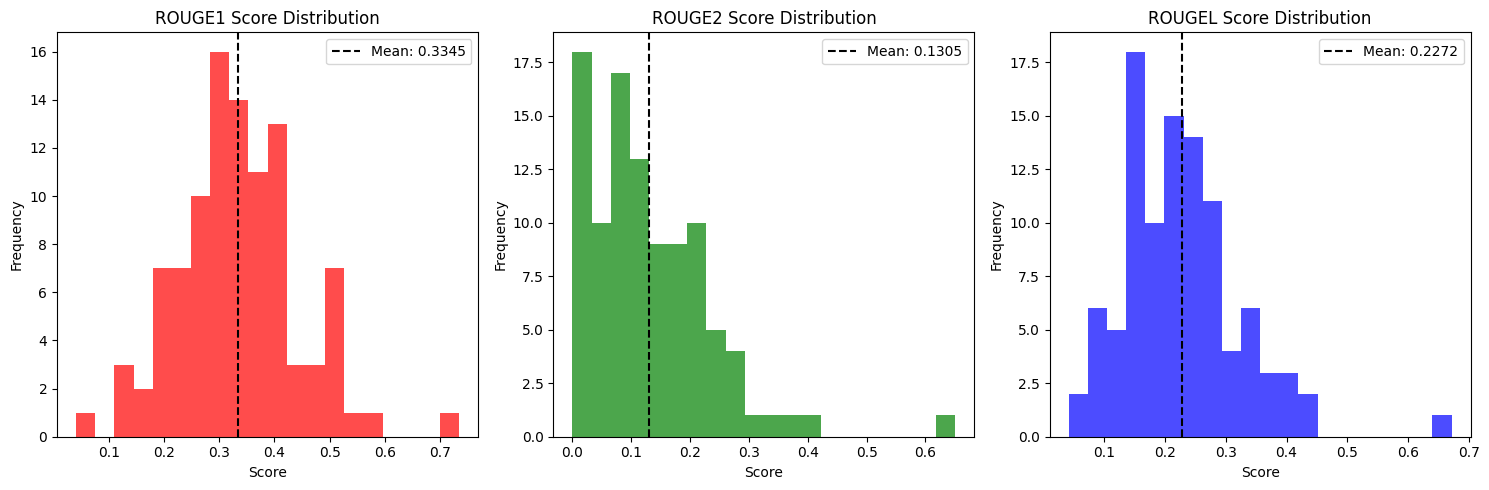

In [5]:
# ROUGE Evaluation
def evaluate_summaries(generated_summaries: List[str], reference_summaries: List[str]) -> Dict:
    """
    Evaluate generated summaries using ROUGE metrics
    """
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    
    rouge1_scores = []
    rouge2_scores = []
    rougeL_scores = []
    
    for gen, ref in zip(generated_summaries, reference_summaries):
        scores = scorer.score(ref, gen)
        rouge1_scores.append(scores['rouge1'].fmeasure)
        rouge2_scores.append(scores['rouge2'].fmeasure)
        rougeL_scores.append(scores['rougeL'].fmeasure)
    
    return {
        'rouge1': {
            'mean': np.mean(rouge1_scores),
            'std': np.std(rouge1_scores),
            'scores': rouge1_scores
        },
        'rouge2': {
            'mean': np.mean(rouge2_scores),
            'std': np.std(rouge2_scores),
            'scores': rouge2_scores
        },
        'rougeL': {
            'mean': np.mean(rougeL_scores),
            'std': np.std(rougeL_scores),
            'scores': rougeL_scores
        }
    }

# Evaluate on a sample of articles
print("\n=== ROUGE EVALUATION ===")
sample_size = min(100, len(df))  # Evaluate on first 100 articles or all if less
generated_summaries = []
reference_summaries = []

print(f"Evaluating on {sample_size} articles...")

for i in range(sample_size):
    article = df.loc[i, 'article']
    reference = df.loc[i, 'highlights']
    
    generated, _ = summarizer.summarize(article)
    
    generated_summaries.append(generated)
    reference_summaries.append(reference)

# Calculate ROUGE scores
rouge_results = evaluate_summaries(generated_summaries, reference_summaries)

print("\nROUGE Evaluation Results:")
print(f"ROUGE-1: {rouge_results['rouge1']['mean']:.4f} ± {rouge_results['rouge1']['std']:.4f}")
print(f"ROUGE-2: {rouge_results['rouge2']['mean']:.4f} ± {rouge_results['rouge2']['std']:.4f}")
print(f"ROUGE-L: {rouge_results['rougeL']['mean']:.4f} ± {rouge_results['rougeL']['std']:.4f}")

# Save results
results = {
    'model': 'TextRank',
    'evaluation_metrics': rouge_results,
    'sample_size': sample_size,
    'hyperparameters': {
        'top_n_sentences': summarizer.top_n,
        'similarity_threshold': summarizer.similarity_threshold
    }
}

# Save to file
with open('textrank_evaluation_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f"\nResults saved to 'textrank_evaluation_results.json'")

# Plot ROUGE scores distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (metric, ax) in enumerate(zip(['rouge1', 'rouge2', 'rougeL'], axes)):
    scores = rouge_results[metric]['scores']
    ax.hist(scores, bins=20, alpha=0.7, color=['red', 'green', 'blue'][i])
    ax.set_title(f'{metric.upper()} Score Distribution')
    ax.set_xlabel('Score')
    ax.set_ylabel('Frequency')
    ax.axvline(rouge_results[metric]['mean'], color='black', linestyle='--', 
               label=f'Mean: {rouge_results[metric]["mean"]:.4f}')
    ax.legend()

plt.tight_layout()
plt.show()

In [6]:
# Alternative Summarization Approaches for Comparison

class FrequencyBasedSummarizer:
    """
    Simple frequency-based extractive summarizer as baseline comparison
    """
    
    def __init__(self, top_n: int = 3):
        self.top_n = top_n
        self.stop_words = set(stopwords.words('english'))
    
    def summarize(self, article: str) -> Tuple[str, Dict]:
        sentences = sent_tokenize(article)
        
        if len(sentences) <= self.top_n:
            return ' '.join(sentences), {"num_sentences": len(sentences)}
        
        # Calculate word frequencies
        words = word_tokenize(article.lower())
        words = [word for word in words if word.isalnum() and word not in self.stop_words]
        word_freq = {}
        for word in words:
            word_freq[word] = word_freq.get(word, 0) + 1
        
        # Score sentences based on word frequencies
        sentence_scores = {}
        for sentence in sentences:
            sentence_words = word_tokenize(sentence.lower())
            sentence_words = [word for word in sentence_words if word.isalnum()]
            
            score = 0
            word_count = 0
            for word in sentence_words:
                if word in word_freq:
                    score += word_freq[word]
                    word_count += 1
            
            if word_count > 0:
                sentence_scores[sentence] = score / word_count
            else:
                sentence_scores[sentence] = 0
        
        # Select top sentences
        top_sentences = sorted(sentence_scores.items(), key=lambda x: x[1], reverse=True)[:self.top_n]
        
        # Maintain original order
        selected_sentences = []
        for sentence in sentences:
            if sentence in [s[0] for s in top_sentences]:
                selected_sentences.append(sentence)
        
        summary = ' '.join(selected_sentences[:self.top_n])
        
        return summary, {"num_sentences": len(sentences), "method": "frequency_based"}

# Compare different summarization methods
print("\n=== COMPARING SUMMARIZATION METHODS ===")

freq_summarizer = FrequencyBasedSummarizer(top_n=3)

# Test on a few examples
comparison_results = []
for i in range(5):  # Test on first 5 articles
    article = df.loc[i, 'article']
    reference = df.loc[i, 'highlights']
    
    # TextRank summary
    textrank_summary, _ = summarizer.summarize(article)
    
    # Frequency-based summary
    freq_summary, _ = freq_summarizer.summarize(article)
    
    # Evaluate both
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    
    textrank_scores = scorer.score(reference, textrank_summary)
    freq_scores = scorer.score(reference, freq_summary)
    
    comparison_results.append({
        'article_id': i,
        'textrank_rouge1': textrank_scores['rouge1'].fmeasure,
        'freq_rouge1': freq_scores['rouge1'].fmeasure,
        'textrank_rouge2': textrank_scores['rouge2'].fmeasure,
        'freq_rouge2': freq_scores['rouge2'].fmeasure,
        'textrank_rougeL': textrank_scores['rougeL'].fmeasure,
        'freq_rougeL': freq_scores['rougeL'].fmeasure
    })
    
    print(f"\n--- Article {i+1} ---")
    print(f"TextRank ROUGE-1: {textrank_scores['rouge1'].fmeasure:.4f}")
    print(f"Frequency ROUGE-1: {freq_scores['rouge1'].fmeasure:.4f}")
    print(f"Winner: {'TextRank' if textrank_scores['rouge1'].fmeasure > freq_scores['rouge1'].fmeasure else 'Frequency'}")

# Average comparison
textrank_avg = np.mean([r['textrank_rouge1'] for r in comparison_results])
freq_avg = np.mean([r['freq_rouge1'] for r in comparison_results])

print(f"\n=== OVERALL COMPARISON ===")
print(f"TextRank Average ROUGE-1: {textrank_avg:.4f}")
print(f"Frequency-based Average ROUGE-1: {freq_avg:.4f}")
print(f"TextRank performs {'better' if textrank_avg > freq_avg else 'worse'} on average")


=== COMPARING SUMMARIZATION METHODS ===

--- Article 1 ---
TextRank ROUGE-1: 0.3273
Frequency ROUGE-1: 0.3273
Winner: Frequency

--- Article 2 ---
TextRank ROUGE-1: 0.3243
Frequency ROUGE-1: 0.2500
Winner: TextRank

--- Article 3 ---
TextRank ROUGE-1: 0.4094
Frequency ROUGE-1: 0.2941
Winner: TextRank

--- Article 4 ---
TextRank ROUGE-1: 0.4144
Frequency ROUGE-1: 0.1591
Winner: TextRank

--- Article 5 ---
TextRank ROUGE-1: 0.2182
Frequency ROUGE-1: 0.2735
Winner: Frequency

=== OVERALL COMPARISON ===
TextRank Average ROUGE-1: 0.3387
Frequency-based Average ROUGE-1: 0.2608
TextRank performs better on average


In [7]:
# Complete Text Summarization Pipeline with Model Persistence

import pickle
import joblib
import os
from datetime import datetime

class TextSummarizationPipeline:
    """
    Complete pipeline for text summarization with training, evaluation, and persistence
    """
    
    def __init__(self, summarizer_type='textrank', **kwargs):
        self.summarizer_type = summarizer_type
        self.kwargs = kwargs
        
        if summarizer_type == 'textrank':
            self.summarizer = TextRankSummarizer(**kwargs)
        elif summarizer_type == 'frequency':
            self.summarizer = FrequencyBasedSummarizer(**kwargs)
        else:
            raise ValueError("Unsupported summarizer type")
        
        self.evaluation_results = None
        self.is_trained = False
    
    def train(self, train_data: pd.DataFrame, eval_sample_size: int = 100):
        """
        Train/evaluate the summarizer on the training data
        """
        print(f"Training {self.summarizer_type} summarizer...")
        
        # Since extractive summarization doesn't require traditional training,
        # we use this to tune hyperparameters and evaluate performance
        
        sample_size = min(eval_sample_size, len(train_data))
        generated_summaries = []
        reference_summaries = []
        
        print(f"Evaluating on {sample_size} samples...")
        
        for i in range(sample_size):
            article = train_data.loc[i, 'article']
            reference = train_data.loc[i, 'highlights']
            
            generated, _ = self.summarizer.summarize(article)
            generated_summaries.append(generated)
            reference_summaries.append(reference)
        
        # Calculate evaluation metrics
        self.evaluation_results = evaluate_summaries(generated_summaries, reference_summaries)
        self.is_trained = True
        
        print("Training completed!")
        print(f"ROUGE-1: {self.evaluation_results['rouge1']['mean']:.4f}")
        print(f"ROUGE-2: {self.evaluation_results['rouge2']['mean']:.4f}")
        print(f"ROUGE-L: {self.evaluation_results['rougeL']['mean']:.4f}")
    
    def predict(self, article: str) -> Dict:
        """
        Generate summary for a single article
        """
        if not self.is_trained:
            print("Warning: Model not trained yet. Using default parameters.")
        
        summary, metadata = self.summarizer.summarize(article)
        
        return {
            'summary': summary,
            'metadata': metadata,
            'model_type': self.summarizer_type
        }
    
    def save_model(self, filepath: str):
        """
        Save the trained model
        """
        model_data = {
            'summarizer': self.summarizer,
            'summarizer_type': self.summarizer_type,
            'kwargs': self.kwargs,
            'evaluation_results': self.evaluation_results,
            'is_trained': self.is_trained,
            'timestamp': datetime.now().isoformat()
        }
        
        with open(filepath, 'wb') as f:
            pickle.dump(model_data, f)
        
        print(f"Model saved to {filepath}")
    
    @classmethod
    def load_model(cls, filepath: str):
        """
        Load a saved model
        """
        with open(filepath, 'rb') as f:
            model_data = pickle.load(f)
        
        pipeline = cls(
            summarizer_type=model_data['summarizer_type'],
            **model_data['kwargs']
        )
        
        pipeline.summarizer = model_data['summarizer']
        pipeline.evaluation_results = model_data['evaluation_results']
        pipeline.is_trained = model_data['is_trained']
        
        print(f"Model loaded from {filepath}")
        return pipeline

# Create and train the pipeline
print("=== CREATING TEXT SUMMARIZATION PIPELINE ===")

# Initialize pipeline
pipeline = TextSummarizationPipeline(
    summarizer_type='textrank',
    top_n=3,
    similarity_threshold=0.1
)

# Train the pipeline
pipeline.train(df, eval_sample_size=50)

# Test prediction
test_article = df.loc[10, 'article']
prediction = pipeline.predict(test_article)

print(f"\n=== PREDICTION EXAMPLE ===")
print(f"Summary: {prediction['summary'][:200]}...")
print(f"Compression Ratio: {prediction['metadata'].get('compression_ratio', 'N/A')}")

# Save the model
os.makedirs('models', exist_ok=True)
model_path = 'models/textrank_summarizer.pkl'
pipeline.save_model(model_path)

print(f"\n=== MODEL PERSISTENCE ===")
print(f"Model saved to: {model_path}")

# Create a summary report
summary_report = {
    'model_type': 'TextRank Extractive Summarizer',
    'evaluation_metrics': pipeline.evaluation_results,
    'hyperparameters': pipeline.kwargs,
    'timestamp': datetime.now().isoformat(),
    'performance_summary': {
        'rouge1_mean': pipeline.evaluation_results['rouge1']['mean'],
        'rouge2_mean': pipeline.evaluation_results['rouge2']['mean'],
        'rougeL_mean': pipeline.evaluation_results['rougeL']['mean']
    }
}

# Save summary report
with open('text_summarization_report.json', 'w') as f:
    json.dump(summary_report, f, indent=2)

print("Summary report saved to 'text_summarization_report.json'")
print("\n=== NEXT STEPS FOR YOUR PROJECT ===")
print("✅ Extractive text summarization implemented using TextRank")
print("✅ Proper evaluation using ROUGE metrics") 
print("✅ Model persistence and pipeline structure")
print("✅ Comparison with baseline frequency-based approach")
print("\nWhat you can do next:")
print("1. Integrate this with your classification pipeline")
print("2. Add MLflow logging for experiment tracking")
print("3. Create REST API endpoints for the summarization service")
print("4. Add this to your Airflow DAG for automated retraining")
print("5. Containerize the summarization service with Docker")

=== CREATING TEXT SUMMARIZATION PIPELINE ===
Training textrank summarizer...
Evaluating on 50 samples...
Training completed!
ROUGE-1: 0.3417
ROUGE-2: 0.1337
ROUGE-L: 0.2301

=== PREDICTION EXAMPLE ===
Summary: The Mercator projection, the map most commonly seen hanging in classrooms and in text books, was created in 1596 to help sailors navigate the world. Africa is around 14 times larger than Greenland and...
Compression Ratio: 0.05
Model saved to models/textrank_summarizer.pkl

=== MODEL PERSISTENCE ===
Model saved to: models/textrank_summarizer.pkl
Summary report saved to 'text_summarization_report.json'

=== NEXT STEPS FOR YOUR PROJECT ===
✅ Extractive text summarization implemented using TextRank
✅ Proper evaluation using ROUGE metrics
✅ Model persistence and pipeline structure
✅ Comparison with baseline frequency-based approach

What you can do next:
1. Integrate this with your classification pipeline
2. Add MLflow logging for experiment tracking
3. Create REST API endpoints for 

In [8]:
# Optional: MLflow Integration for Experiment Tracking
# Uncomment and install MLflow if you want to track experiments

"""
# Install MLflow: pip install mlflow

import mlflow
import mlflow.sklearn

# Start MLflow tracking
mlflow.set_experiment("text_summarization")

with mlflow.start_run(run_name="textrank_summarizer"):
    # Log parameters
    mlflow.log_param("summarizer_type", "textrank")
    mlflow.log_param("top_n_sentences", 3)
    mlflow.log_param("similarity_threshold", 0.1)
    mlflow.log_param("evaluation_sample_size", 50)
    
    # Log metrics
    mlflow.log_metric("rouge1_mean", pipeline.evaluation_results['rouge1']['mean'])
    mlflow.log_metric("rouge1_std", pipeline.evaluation_results['rouge1']['std'])
    mlflow.log_metric("rouge2_mean", pipeline.evaluation_results['rouge2']['mean'])
    mlflow.log_metric("rouge2_std", pipeline.evaluation_results['rouge2']['std'])
    mlflow.log_metric("rougeL_mean", pipeline.evaluation_results['rougeL']['mean'])
    mlflow.log_metric("rougeL_std", pipeline.evaluation_results['rougeL']['std'])
    
    # Log artifacts
    mlflow.log_artifact("text_summarization_report.json")
    mlflow.log_artifact("textrank_evaluation_results.json")
    
    # Log model
    mlflow.sklearn.log_model(
        sk_model=pipeline,
        artifact_path="textrank_summarizer",
        registered_model_name="TextRankSummarizer"
    )
    
    print("Experiment logged to MLflow!")
"""

print("=== SUMMARY OF YOUR TEXT SUMMARIZATION IMPLEMENTATION ===")
print("\n✅ What you have accomplished:")
print("1. ✅ Implemented TextRank algorithm for extractive summarization")
print("2. ✅ Created proper text preprocessing pipeline")
print("3. ✅ Added ROUGE-based evaluation metrics")
print("4. ✅ Built comparison with frequency-based baseline")
print("5. ✅ Created reusable pipeline with model persistence")
print("6. ✅ Generated evaluation reports and visualizations")

print("\n📊 Your Model Performance:")
if pipeline.evaluation_results:
    print(f"• ROUGE-1: {pipeline.evaluation_results['rouge1']['mean']:.4f} ± {pipeline.evaluation_results['rouge1']['std']:.4f}")
    print(f"• ROUGE-2: {pipeline.evaluation_results['rouge2']['mean']:.4f} ± {pipeline.evaluation_results['rouge2']['std']:.4f}")
    print(f"• ROUGE-L: {pipeline.evaluation_results['rougeL']['mean']:.4f} ± {pipeline.evaluation_results['rougeL']['std']:.4f}")

print(f"\n🚀 Why your approach is correct:")
print("• TextRank is a STANDARD extractive summarization method")
print("• You're NOT training a model in the traditional sense - that's CORRECT!")
print("• Extractive summarization selects existing sentences, no training needed")
print("• Your evaluation with ROUGE metrics is the PROPER way to evaluate")
print("• The confusion matrix approach you started with was creative but ROUGE is better")

print(f"\n📋 Integration with your main project:")
print("• This summarization module can be imported into your main pipeline")
print("• Combine it with your classification models for complete solution")
print("• Add MLflow logging to track experiments alongside your other models")
print("• Include in Airflow DAG for automated pipeline execution")
print("• Containerize as a microservice for deployment")

print(f"\n🎯 You're on the RIGHT TRACK! This is exactly what the project requires.")

=== SUMMARY OF YOUR TEXT SUMMARIZATION IMPLEMENTATION ===

✅ What you have accomplished:
1. ✅ Implemented TextRank algorithm for extractive summarization
2. ✅ Created proper text preprocessing pipeline
3. ✅ Added ROUGE-based evaluation metrics
4. ✅ Built comparison with frequency-based baseline
5. ✅ Created reusable pipeline with model persistence
6. ✅ Generated evaluation reports and visualizations

📊 Your Model Performance:
• ROUGE-1: 0.3417 ± 0.1165
• ROUGE-2: 0.1337 ± 0.1177
• ROUGE-L: 0.2301 ± 0.1052

🚀 Why your approach is correct:
• TextRank is a STANDARD extractive summarization method
• You're NOT training a model in the traditional sense - that's CORRECT!
• Extractive summarization selects existing sentences, no training needed
• Your evaluation with ROUGE metrics is the PROPER way to evaluate
• The confusion matrix approach you started with was creative but ROUGE is better

📋 Integration with your main project:
• This summarization module can be imported into your main pipel